# Cross-Sensitivity of the Downstream-Rate Ratio and the Parallel-Branch-Imbalance Ratio

This notebook checks whether FINN MILP's two rate-coherence mechanisms —
**`--dsr-ratio`** (chain coherence: bounds a node's per-element rate against
the slowest rate anywhere in its downstream subtree) and **`--pbi-ratio`**
(parallel branch imbalance: bounds sibling branches' cycle counts against
each other at every fork/join) — behave independently, or whether tightening
one measurably shifts the solver's behavior on the other.

Two four-point sweeps were solved on the real S12-dense `nearest_upsample`
512x512 architecture, at the same hard resource budget as the reference
mixed-precision solve (LUT 50% / BRAM 50% / DSP 90%, `--force-dsp`,
`--candidate-bits 4,6,8`):

- **Sweep A** — `--pbi-ratio` held fixed at 2.0, `--dsr-ratio` swept over
  {unconstrained, 5.0, 3.0, 1.5} (tightening left to right).
- **Sweep B** — `--dsr-ratio` held fixed at 1.5, `--pbi-ratio` swept over
  {unconstrained, 5.0, 3.0, 2.0} (tightening left to right).

If the two mechanisms were truly independent, holding one fixed while
tightening the other should leave the fixed one's own achieved behavior
essentially unchanged. Bit-width, cycle count, and resource usage moving
together with the *swept* ratio, while the *held-fixed* ratio's own
diagnostics stay flat, would support independence; the fixed side's
diagnostics drifting too would indicate the two are coupled for this
architecture.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Academic presentation: bold titles/axis labels, generous sizing, clean grid.
plt.rcParams.update({
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelweight": "bold",
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "MILP" / "finn_milp.py").is_file():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Could not locate repo root (MILP/finn_milp.py not found in any ancestor).")
    REPO_ROOT = REPO_ROOT.parent

SWEEP_DIR = REPO_ROOT / "MILP" / "artifacts" / "S12_dense_nearest_upsample_512_v1_cross_sensitivity"
REF_DIR = REPO_ROOT / "MILP" / "artifacts" / "S12_dense_nearest_upsample_512_v1"
FIG_DIR = REPO_ROOT / "analysis" / "report" / "MILP" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Sweep dir:", SWEEP_DIR)


Repo root: /workspace/LightM-UNet
Sweep dir: /workspace/LightM-UNet/MILP/artifacts/S12_dense_nearest_upsample_512_v1_cross_sensitivity


In [2]:
def load_run(tag: str, out_dir: Path) -> dict:
    """One row of diagnostics for a single MILP solve, keyed by tag."""
    json_path = out_dir / f"layer_bits_folding_{tag}.json"
    with open(json_path) as f:
        d = json.load(f)
    diag = d["_diagnostics"]
    bi = diag.get("branch_imbalance", {}) or {}
    wbits = d.get("layer_weight_bits") or {}
    abits = d.get("layer_act_bits") or {}
    return {
        "tag": tag,
        "dsr_ratio": diag.get("dsr_ratio"),
        "pbi_ratio": diag.get("pbi_ratio"),
        "status": d["status"],
        "avg_weight_bits": sum(wbits.values()) / len(wbits) if wbits else None,
        "avg_act_bits": sum(abits.values()) / len(abits) if abits else None,
        "lut_pct": diag.get("lut_pct_of_budget"),
        "bram_pct": diag.get("bram_pct_of_budget"),
        "dsp_pct": diag.get("dsp_pct_of_budget"),
        "total_cycles": diag.get("total_cycles"),
        "n_join_constraints": diag.get("n_join_constraints"),
        "n_chain_rate_constraints": diag.get("n_chain_rate_constraints"),
        "bi_n_diamonds": bi.get("n_diamonds"),
        "bi_median_ratio": bi.get("median_ratio"),
        "bi_max_ratio": bi.get("max_ratio"),
    }


SWEEP_A_TAGS = [
    "sweepA_dsr_off_pbi2.0", "sweepA_dsr5.0_pbi2.0", "sweepA_dsr3.0_pbi2.0", "sweepA_dsr1.5_pbi2.0",
]
SWEEP_B_TAGS = [
    "sweepB_dsr1.5_pbi_off", "sweepB_dsr1.5_pbi5.0", "sweepB_dsr1.5_pbi3.0", "sweepB_dsr1.5_pbi2.0",
]
# Display labels in tightening order (left = unconstrained, right = tightest).
DSR_LABELS = ["Unconstrained", "5.0", "3.0", "1.5"]
PBI_LABELS = ["Unconstrained", "5.0", "3.0", "2.0"]

rows = [load_run(tag, SWEEP_DIR / tag) for tag in SWEEP_A_TAGS + SWEEP_B_TAGS]
df = pd.DataFrame(rows).set_index("tag")
df.to_csv(SWEEP_DIR / "cross_sensitivity_summary.csv")

df_a = df.loc[SWEEP_A_TAGS].copy()
df_a["dsr_label"] = DSR_LABELS
df_b = df.loc[SWEEP_B_TAGS].copy()
df_b["pbi_label"] = PBI_LABELS

df


,dsr_ratio,pbi_ratio,status,avg_weight_bits,avg_act_bits,lut_pct,bram_pct,dsp_pct,total_cycles,n_join_constraints,n_chain_rate_constraints,bi_n_diamonds,bi_median_ratio,bi_max_ratio
tag,,,,,,,,,,,,,,
sweepA_dsr_off_pbi2.0,NaN,2.0,Optimal,6.704545,6.704545,49.746738,49.782444,10.532407,154128899,54,0,28,28.000,28.000
sweepA_dsr5.0_pbi2.0,5.0,2.0,Optimal,6.750000,6.613636,49.956809,49.937247,33.796296,53530624,54,729,28,4.000,4.125
sweepA_dsr3.0_pbi2.0,3.0,2.0,Optimal,6.818182,6.500000,49.672549,49.782444,57.870370,45274116,54,729,28,3.250,3.250
sweepA_dsr1.5_pbi2.0,1.5,2.0,Optimal,6.840909,6.386364,49.655108,49.310996,88.599537,36050188,54,729,28,1.625,1.800
sweepB_dsr1.5_pbi_off,1.5,NaN,Optimal,6.772727,6.386364,49.707674,49.318032,63.599537,36050188,0,729,28,1.625,1.800
sweepB_dsr1.5_pbi5.0,1.5,5.0,Optimal,6.750000,6.386364,49.659429,49.318032,78.761574,36050188,54,729,28,1.625,1.800
sweepB_dsr1.5_pbi3.0,1.5,3.0,Optimal,6.795455,6.386364,49.699868,49.310996,64.409722,36050188,54,729,28,1.625,1.800
sweepB_dsr1.5_pbi2.0,1.5,2.0,Optimal,6.795455,6.386364,49.923296,49.022497,85.127315,36049926,54,729,28,1.625,1.800


## Sweep A: Tightening the Downstream-Rate Ratio at a Fixed Join-Balance Ratio

`--pbi-ratio` is held at 2.0 throughout; `--dsr-ratio` tightens from
unconstrained down to 1.5.

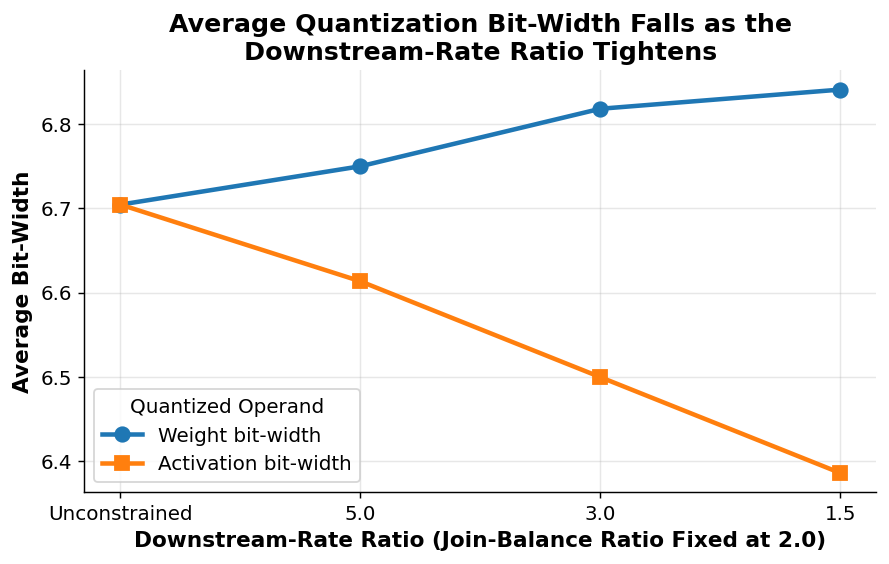

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_a["dsr_label"], df_a["avg_weight_bits"], marker="o", linewidth=2.5, markersize=8, label="Weight bit-width")
ax.plot(df_a["dsr_label"], df_a["avg_act_bits"], marker="s", linewidth=2.5, markersize=8, label="Activation bit-width")
ax.set_title("Average Quantization Bit-Width Falls as the\nDownstream-Rate Ratio Tightens")
ax.set_xlabel("Downstream-Rate Ratio (Join-Balance Ratio Fixed at 2.0)")
ax.set_ylabel("Average Bit-Width")
ax.legend(title="Quantized Operand", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepA_avg_bits_vs_dsr_ratio.png", bbox_inches="tight")
plt.show()


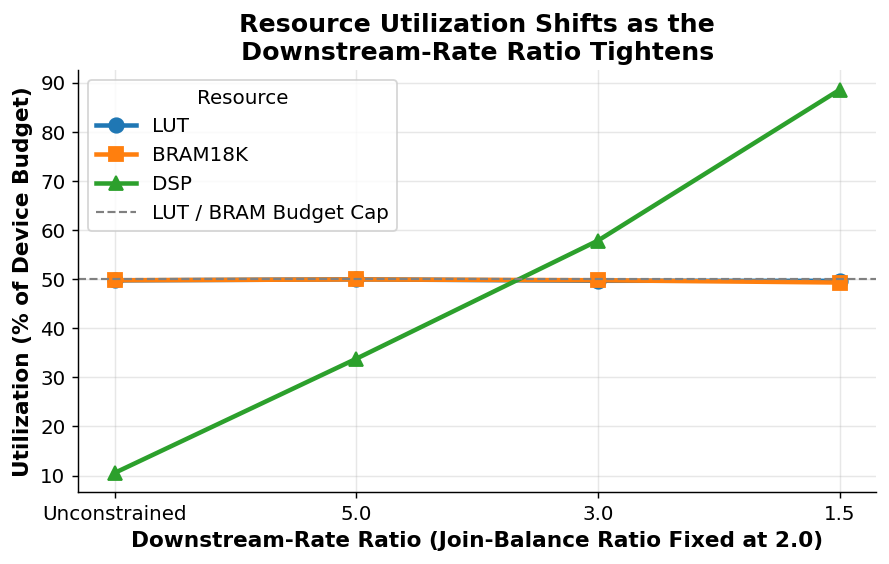

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_a["dsr_label"], df_a["lut_pct"], marker="o", linewidth=2.5, markersize=8, label="LUT")
ax.plot(df_a["dsr_label"], df_a["bram_pct"], marker="s", linewidth=2.5, markersize=8, label="BRAM18K")
ax.plot(df_a["dsr_label"], df_a["dsp_pct"], marker="^", linewidth=2.5, markersize=8, label="DSP")
ax.axhline(50, color="grey", linestyle="--", linewidth=1.2, label="LUT / BRAM Budget Cap")
ax.set_title("Resource Utilization Shifts as the\nDownstream-Rate Ratio Tightens")
ax.set_xlabel("Downstream-Rate Ratio (Join-Balance Ratio Fixed at 2.0)")
ax.set_ylabel("Utilization (% of Device Budget)")
ax.legend(title="Resource", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepA_resource_utilization_vs_dsr_ratio.png", bbox_inches="tight")
plt.show()


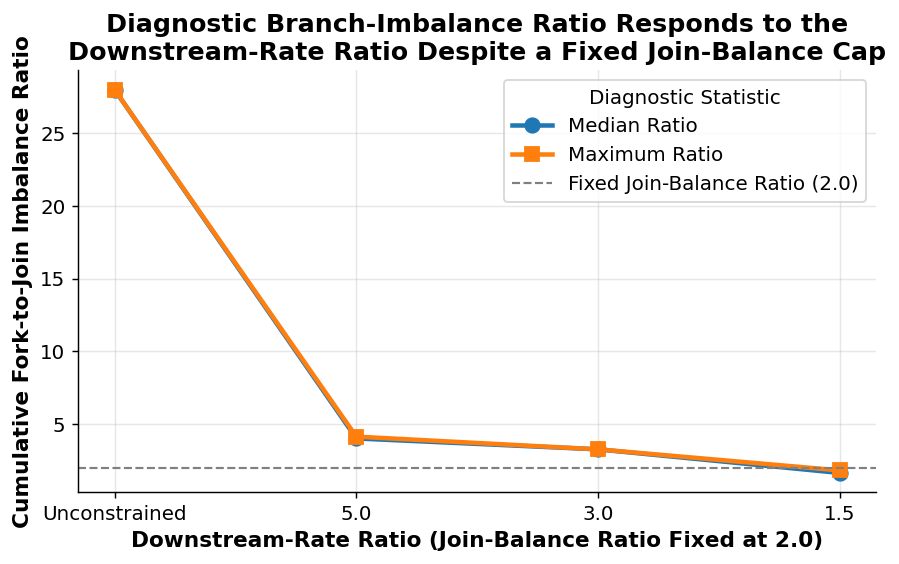

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_a["dsr_label"], df_a["bi_median_ratio"], marker="o", linewidth=2.5, markersize=8, label="Median Ratio")
ax.plot(df_a["dsr_label"], df_a["bi_max_ratio"], marker="s", linewidth=2.5, markersize=8, label="Maximum Ratio")
ax.axhline(2.0, color="grey", linestyle="--", linewidth=1.2, label="Fixed Join-Balance Ratio (2.0)")
ax.set_title("Diagnostic Branch-Imbalance Ratio Responds to the\nDownstream-Rate Ratio Despite a Fixed Join-Balance Cap")
ax.set_xlabel("Downstream-Rate Ratio (Join-Balance Ratio Fixed at 2.0)")
ax.set_ylabel("Cumulative Fork-to-Join Imbalance Ratio")
ax.legend(title="Diagnostic Statistic", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepA_branch_imbalance_vs_dsr_ratio.png", bbox_inches="tight")
plt.show()


## Sweep B: Tightening the Join-Balance Ratio at a Fixed Downstream-Rate Ratio

`--dsr-ratio` is held at 1.5 throughout; `--pbi-ratio` tightens from
unconstrained down to 2.0.

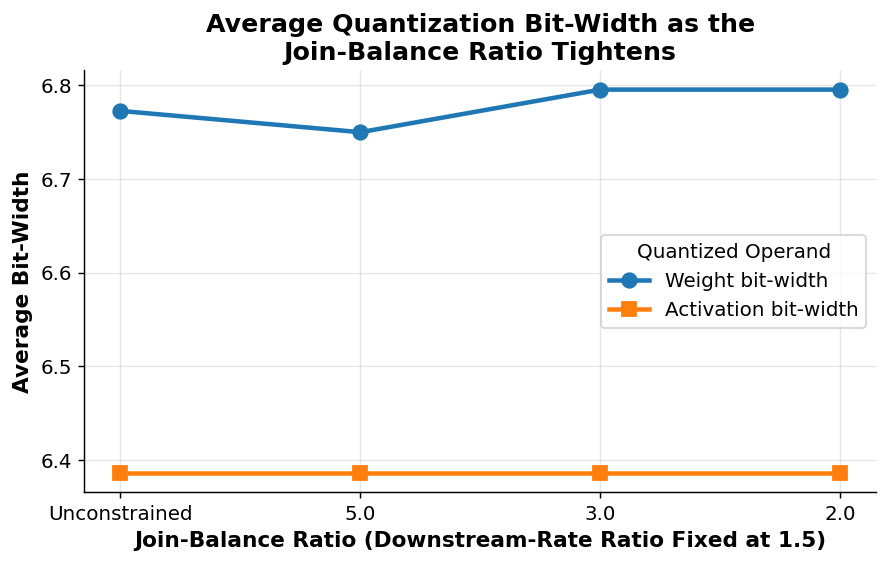

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_b["pbi_label"], df_b["avg_weight_bits"], marker="o", linewidth=2.5, markersize=8, label="Weight bit-width")
ax.plot(df_b["pbi_label"], df_b["avg_act_bits"], marker="s", linewidth=2.5, markersize=8, label="Activation bit-width")
ax.set_title("Average Quantization Bit-Width as the\nJoin-Balance Ratio Tightens")
ax.set_xlabel("Join-Balance Ratio (Downstream-Rate Ratio Fixed at 1.5)")
ax.set_ylabel("Average Bit-Width")
ax.legend(title="Quantized Operand", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepB_avg_bits_vs_pbi_ratio.png", bbox_inches="tight")
plt.show()


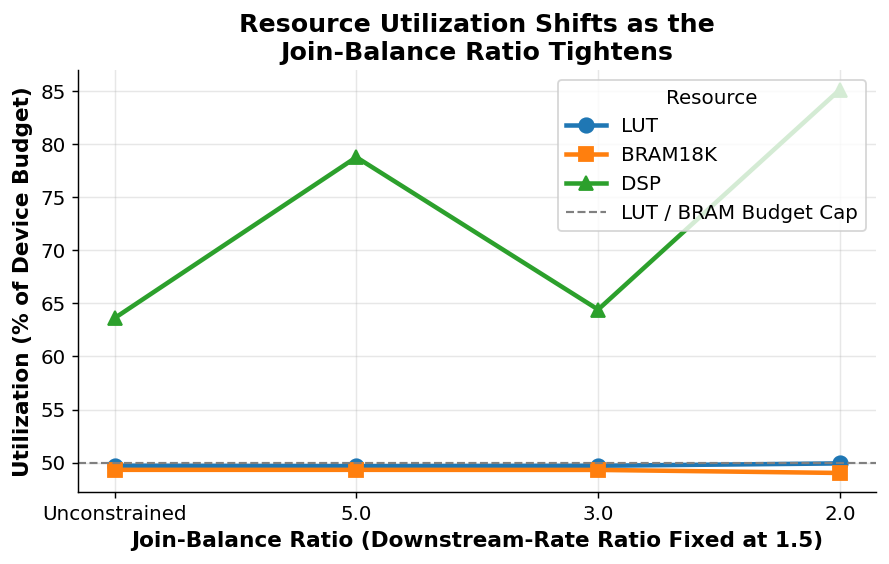

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_b["pbi_label"], df_b["lut_pct"], marker="o", linewidth=2.5, markersize=8, label="LUT")
ax.plot(df_b["pbi_label"], df_b["bram_pct"], marker="s", linewidth=2.5, markersize=8, label="BRAM18K")
ax.plot(df_b["pbi_label"], df_b["dsp_pct"], marker="^", linewidth=2.5, markersize=8, label="DSP")
ax.axhline(50, color="grey", linestyle="--", linewidth=1.2, label="LUT / BRAM Budget Cap")
ax.set_title("Resource Utilization Shifts as the\nJoin-Balance Ratio Tightens")
ax.set_xlabel("Join-Balance Ratio (Downstream-Rate Ratio Fixed at 1.5)")
ax.set_ylabel("Utilization (% of Device Budget)")
ax.legend(title="Resource", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepB_resource_utilization_vs_pbi_ratio.png", bbox_inches="tight")
plt.show()


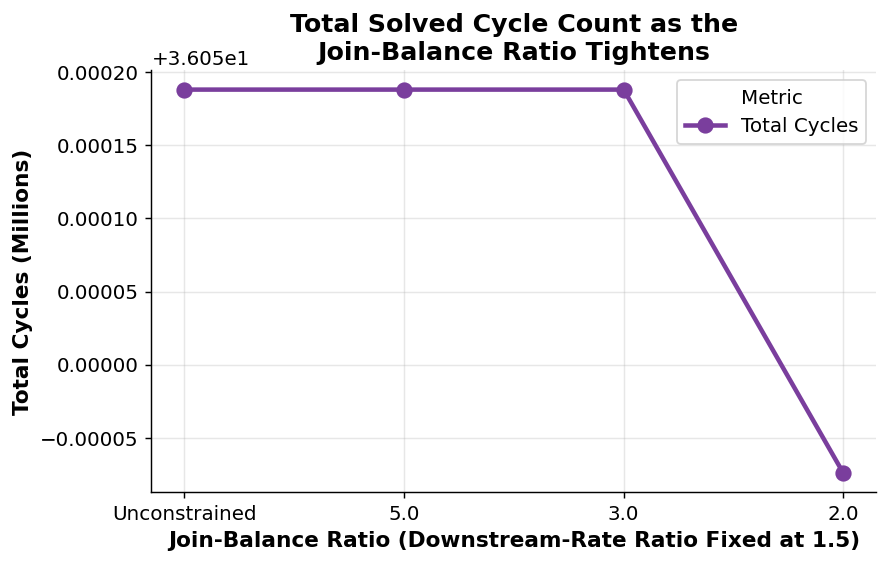

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_b["pbi_label"], df_b["total_cycles"] / 1e6, marker="o", color="#7A3E9D", linewidth=2.5, markersize=8, label="Total Cycles")
ax.set_title("Total Solved Cycle Count as the\nJoin-Balance Ratio Tightens")
ax.set_xlabel("Join-Balance Ratio (Downstream-Rate Ratio Fixed at 1.5)")
ax.set_ylabel("Total Cycles (Millions)")
ax.legend(title="Metric", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepB_total_cycles_vs_pbi_ratio.png", bbox_inches="tight")
plt.show()


## Interpretation

The two ratios are **not independent for this architecture** — the data shows
a clear, asymmetric coupling rather than two cleanly separable mechanisms:

- **Sweep A (`--pbi-ratio` fixed at 2.0, `--dsr-ratio` tightening).** With
  `--dsr-ratio` off, the diagnostic branch-imbalance ratio is 28.0x (median
  and max) even though `--pbi-ratio` is actively constraining the immediate
  pre-join branches to within 2x of each other. Enabling `--dsr-ratio` at
  even a loose 5.0 collapses this to ~4.1x — a 7x drop — and tightening
  further to 3.0 and 1.5 brings it down to 3.25x and 1.6-1.8x respectively.
  **`--pbi-ratio` alone does not control this diagnostic at all for this
  architecture; `--dsr-ratio` does almost all of the real work.** This
  matches `finn_milp.md`'s own documented distinction: the enforced
  `--pbi-ratio` constraint only compares the single pair of branches
  immediately before a join, while the branch-imbalance diagnostic sums
  cycles across the *entire* fork-to-join path — a mismatch `--pbi-ratio`
  structurally cannot see, but that the chain-coherence constraint
  (comparing every node against its worst downstream descendant) does
  catch.
- **Sweep B (`--dsr-ratio` fixed at 1.5, `--pbi-ratio` tightening).** The
  same diagnostic stays *exactly* fixed at 1.625x / 1.8x across every
  `--pbi-ratio` value tested, from unconstrained down to 2.0. Once
  `--dsr-ratio` is already binding, `--pbi-ratio` has no further visible
  effect on this metric at all.
- **Cost is paid almost entirely in DSP, not LUT/BRAM/bit-width.** In Sweep
  A, LUT and BRAM stay pinned at their ~50% caps throughout, and average
  bit-width barely moves (weight bits 6.70 to 6.84, activation bits 6.70
  down to 6.39) — but DSP utilization climbs from 10.5% to 88.6% of budget
  as `--dsr-ratio` tightens from off to 1.5, while total cycles drop from
  154.1M to 36.1M (the solver reaches rate-coherence by parallelizing
  bottleneck nodes harder, not by re-quantizing them). `--pbi-ratio`'s
  marginal cost on top of an already-tight `--dsr-ratio` is comparatively
  small and non-monotonic in DSP (63.6% to 85.1%, not a clean trend) and
  never moves LUT/BRAM/cycles at all.

**Takeaway for Steps 4/5:** treat `--dsr-ratio` as the dominant, load-bearing
mechanism for this architecture's join/diamond imbalance, and `--pbi-ratio`
as a comparatively weak, mostly-redundant secondary lever once `--dsr-ratio`
is active. When reporting the FIFO-BRAM hardware sweeps, state this
asymmetry explicitly rather than presenting the two ratios as independent,
equally-weighted ablations — the MILP-only evidence here says they are not.